# 37 — Confusion Matrix

## Goal
To visualize which activities the model predicts correctly and which ones it confuses.

## Research Question
Which activities are easiest or hardest for the model to classify?

## Confusion matrix

A confusion matrix compares actual labels with predicted labels.

- Diagonal cells show correct predictions.
- Off-diagonal cells show mistakes.

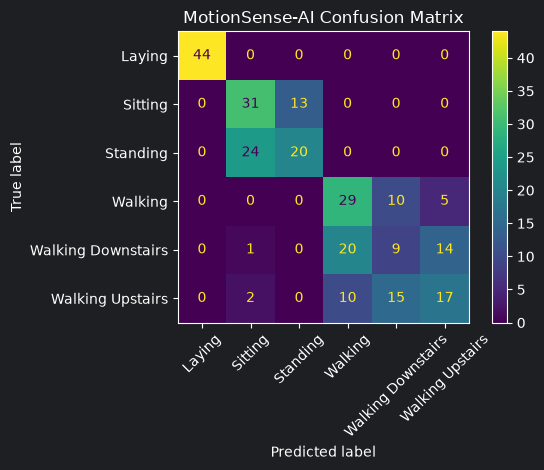

In [2]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
ML_READY_PATH = PROCESSED_DIR / "motionsense_ml_ready.csv"

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

df = pd.read_csv(ML_READY_PATH)
feature_columns = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "acc_magnitude", "gyro_magnitude"
]
X = df[feature_columns]
y = df["activity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Display the confusion matrix as a chart.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    xticks_rotation=45
)
plt.title("MotionSense-AI Confusion Matrix")
plt.tight_layout()
plt.show()

## Key idea

Accuracy gives an overall measure of correct predictions.

A confusion matrix shows where the model is making mistakes.